# Course project

This notebook includes the code for the course project in the DTU course [Integrated Energy Grids](https://kurser.dtu.dk/course/2024-2025/46770?menulanguage=en)  and is modelling and analyzing the german energy system. 
 
The report is provided along this notebook, further explaining the results. 

### Imports

In [1]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [4]:
import os
import sys

# Set path to the directory containing base.py
module_path = os.path.abspath(".")

if module_path not in sys.path:
    sys.path.append(module_path)

from base import *
from visualization import *

## D. Introducing Storage Technology 
Add some storage technology/ies and investigate how they behave and what their impact is on the optimal system configuration. Discuss what strategies is your system using to balance the renewable generation at different time scales (intraday, seasonal, etc.)


In [5]:
n_storage = base.build_network(solve=False)

c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  network.set_snapshots(pd.date_range(f"{year}-01-01", f"{year}-12-31 23:00", freq="H"))
c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour
c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:95: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  inflow_ror_hourly = df_daily["Inflow [MW]"].resample("H").int

In [7]:
costs = base.get_costs()
costs

AttributeError: module 'base' has no attribute 'get_costs'

In [ ]:
# add battery

network.add(
    "StorageUnit",
    "battery storage",
    bus="electricity",
    carrier="battery storage",
    max_hours=2,
    capital_cost=costs.at["battery inverter", "capital_cost"]
    + 2 * costs.at["battery storage", "capital_cost"],
    efficiency_store=costs.at["battery inverter", "efficiency"],
    efficiency_dispatch=costs.at["battery inverter", "efficiency"],
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)

In [22]:
# how to use base module:

# 1. Initilize Base model
# network = base.build_network(solve=False)  # just builds it

# 2. Edit/add components based on assignment details
# do some edits...

# 3. Solve model
# network.optimize(solver_name="highs")  # solve manually later

In [5]:
network.optimize(solver_name="highs")

Index(['DEU_elec'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 21.33it/s]
INFO:linopy.io: Writing time: 0.74s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 70088 primals, 148930 duals
Objective: 3.09e+10
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

<Axes: xlabel='snapshot', ylabel='CF'>

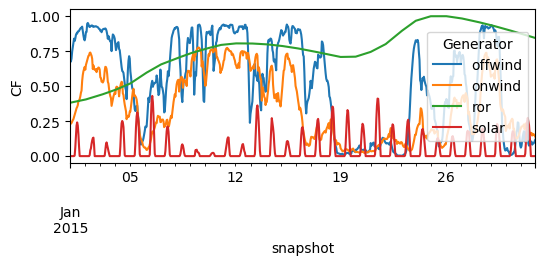

In [12]:
network.generators_t.p_max_pu.loc["2015-01"].plot(figsize=(6, 2), ylabel="CF")

System Cost: 30.89 billion euros

Optimal Generator Capacities (GW):
Generator
coal           -0.000000
lignite        30.000000
biomass CHP     5.000000
OCGT           41.340161
ror            -0.000000
onwind          1.667861
offwind         5.296146
solar          10.865676
Name: p_nom_opt, dtype: float64

Optimal Annual Energy Generation (GWh):
Generator
coal             0.000000
lignite        258.381525
biomass CHP     43.800000
OCGT           172.112938
ror              0.000000
onwind           3.083360
offwind         16.682891
solar           11.203848
dtype: float64


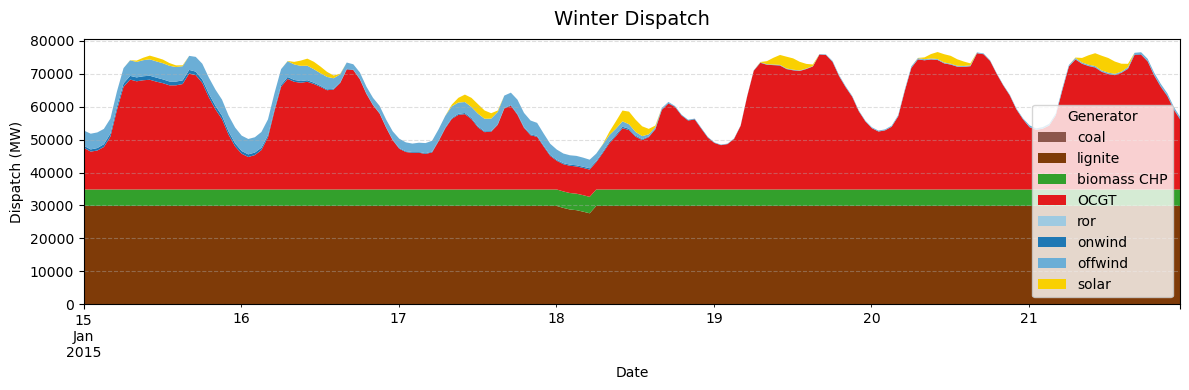

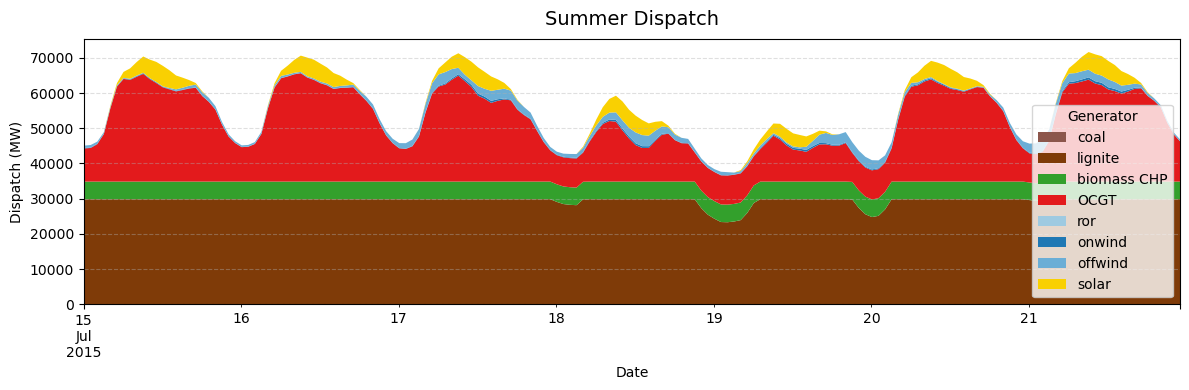

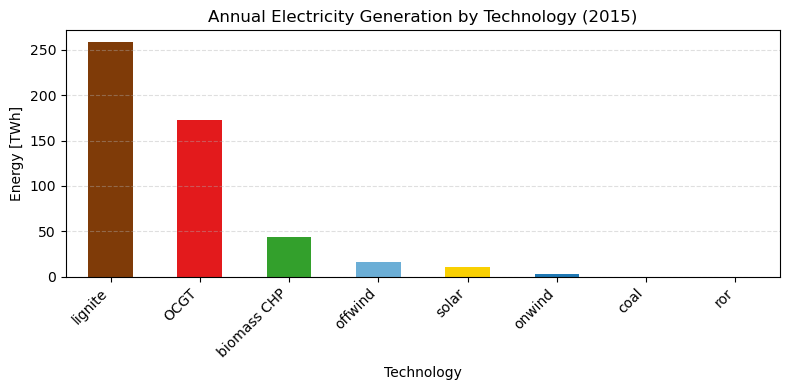

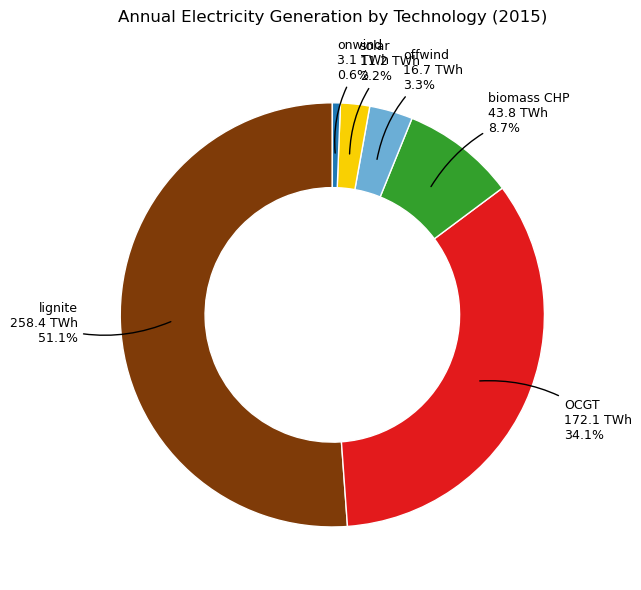

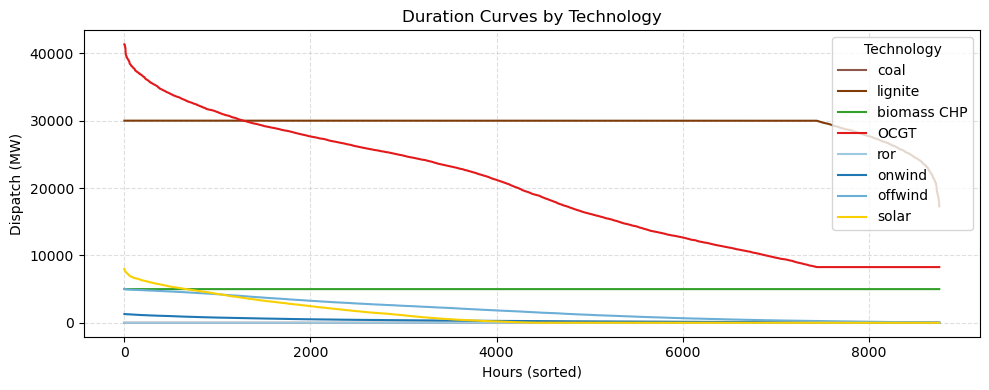

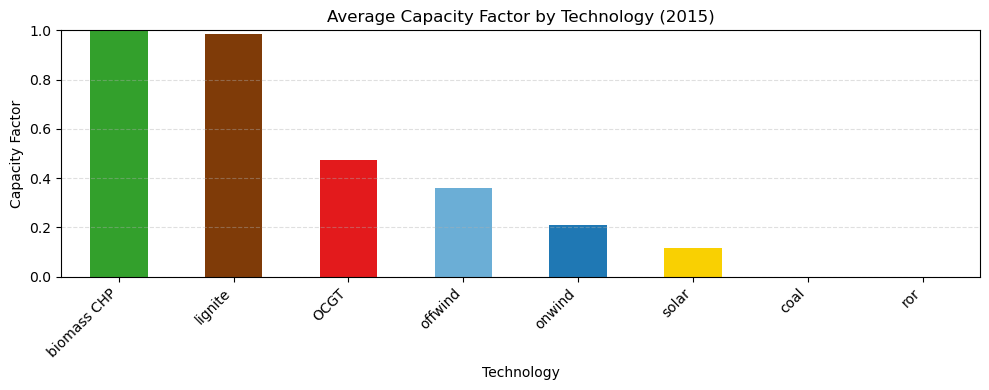

In [21]:
print_summary(network)
# Plot winter week
plot_dispatch_week(network, "2015-01-15", "2015-01-21", "Winter Dispatch")
# Plot summer week
plot_dispatch_week(network,"2015-07-15", "2015-07-21", "Summer Dispatch")
plot_generation_bar(network)
plot_generation_pie(network)
plot_duration_curves(network)
plot_capacity_factors(network)

In [16]:
network.generators_t.p.loc["2015-01-15":"2015-01-21"]

Generator,coal,lignite,biomass CHP,OCGT,ror,onwind,offwind,solar
snapshot,,,,,,,,
2015-01-15 00:00:00,-0.0,30000.0,5000.0,12613.189361,-0.0,592.090699,4644.719939,-0.0
2015-01-15 01:00:00,-0.0,30000.0,5000.0,11495.659978,-0.0,663.808728,4766.531295,-0.0
2015-01-15 02:00:00,-0.0,30000.0,5000.0,11815.783644,-0.0,748.869645,4745.346711,-0.0
2015-01-15 03:00:00,-0.0,30000.0,5000.0,12887.049769,-0.0,838.934146,4650.016085,-0.0
2015-01-15 04:00:00,-0.0,30000.0,5000.0,16030.012582,-0.0,939.005813,4559.981605,-0.0
...,...,...,...,...,...,...,...,...
2015-01-21 19:00:00,-0.0,30000.0,5000.0,34553.411610,-0.0,176.793279,693.795111,-0.0
2015-01-21 20:00:00,-0.0,30000.0,5000.0,31141.357700,-0.0,200.143335,688.498965,-0.0
2015-01-21 21:00:00,-0.0,30000.0,5000.0,28329.351569,-0.0,206.814779,640.833652,-0.0
